<a href="https://colab.research.google.com/github/vakaramyasri1204-alt/Customer-Segmentation-Churn-Prediction-Online-Retail-II/blob/main/online_retail_II_pandas_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
for f in os.listdir('/content'):
    print(f)


.config
online_retail_II.csv.xlsx
sample_data


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Online Retail II ships as an Excel file with two sheets (2009-2010 and 2010-2011)
excel_file = pd.ExcelFile('/content/online_retail_II.csv.xlsx')
print("Available sheet names:", excel_file.sheet_names)

# It appears there is only one sheet named 'online_retail_II'. Reading this sheet.
df = pd.read_excel(excel_file, sheet_name='online_retail_II')

print(df.shape)
df.head()
df.info()

Available sheet names: ['online_retail_II']
(1048575, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1048575 non-null  object        
 1   StockCode    1048575 non-null  object        
 2   Description  1044203 non-null  object        
 3   Quantity     1048575 non-null  int64         
 4   InvoiceDate  1048575 non-null  datetime64[ns]
 5   Price        1048575 non-null  float64       
 6   Customer ID  811893 non-null   float64       
 7   Country      1048575 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 64.0+ MB


In [9]:
# Drop rows with no Customer ID (can't attribute to a customer)
df = df.dropna(subset=['Customer ID'])

# Remove cancellations (Invoice starting with 'C') and negative/zero quantities
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Create a revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Confirm date range
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min(), df['InvoiceDate'].max())

2009-12-01 07:45:00 2011-12-04 13:15:00


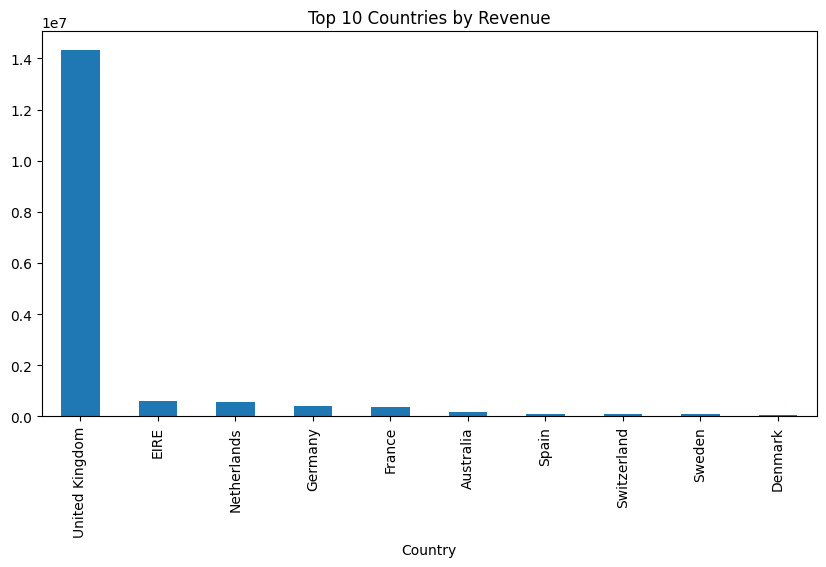

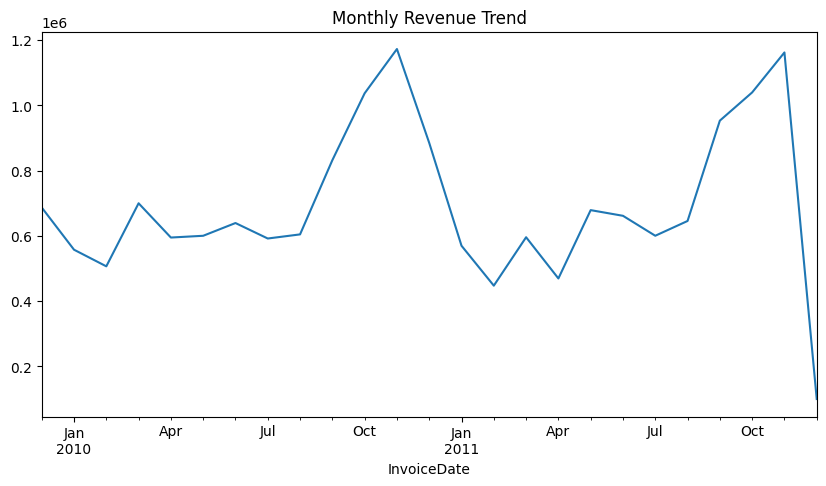

Description
REGENCY CAKESTAND 3 TIER              282511.72
WHITE HANGING HEART T-LIGHT HOLDER    250513.22
Manual                                151913.11
JUMBO BAG RED RETROSPOT               136139.64
ASSORTED COLOUR BIRD ORNAMENT         126052.47
POSTAGE                               124442.04
PARTY BUNTING                         103627.78
MEDIUM CERAMIC TOP STORAGE JAR         81243.22
PAPER CHAIN KIT 50'S CHRISTMAS         76906.96
CHILLI LIGHTS                          71631.82
Name: Revenue, dtype: float64


In [10]:
# Revenue by country
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_rev.plot(kind='bar', figsize=(10,5), title='Top 10 Countries by Revenue')
plt.show()

# Monthly revenue trend
monthly_rev = df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
monthly_rev.plot(figsize=(10,5), title='Monthly Revenue Trend')
plt.show()

# Top products by revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

In [11]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                      # Frequency
    'Revenue': 'sum'                                            # Monetary
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,321,12,77556.46
12347.0,35,7,5408.50
12348.0,71,5,2019.40
12349.0,14,4,4428.69
12350.0,305,1,334.40


In [12]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 7:
        return 'At Risk'
    else:
        return 'Lost / Low Value'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
Lost / Low Value,1749
At Risk,1456
Loyal Customers,1365
Champions,1290


                     Recency  Frequency     Monetary  Customer_Count  \
Segment                                                                
At Risk           201.531593   2.640110   848.891313            1456   
Champions          26.802326  17.765891  9782.549364            1290   
Lost / Low Value  409.116638   1.246998   302.709144            1749   
Loyal Customers    98.320879   5.504762  2153.860341            1365   

                  Revenue_Share  
Segment                          
At Risk                0.071341  
Champions              0.728400  
Lost / Low Value       0.030559  
Loyal Customers        0.169699  


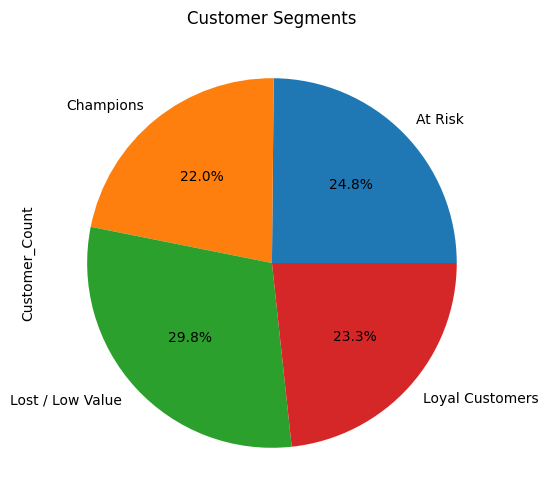

In [13]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean', 'Segment': 'count'
}).rename(columns={'Segment': 'Customer_Count'})
segment_summary['Revenue_Share'] = rfm.groupby('Segment')['Monetary'].sum() / rfm['Monetary'].sum()
print(segment_summary)

segment_summary['Customer_Count'].plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Customer Segments')
plt.show()

In [14]:
# Using your existing rfm dataframe
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)
rfm['Churned'].value_counts(normalize=True)

,proportion
Churned,
1,0.51314
0,0.48686


In [15]:
customer_features = df.groupby('Customer ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Total_Items=('Quantity', 'sum'),
    Avg_Order_Value=('Revenue', lambda x: x.sum() / df.loc[x.index, 'Invoice'].nunique()),
    Distinct_Products=('StockCode', 'nunique'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
)

customer_features['Customer_Tenure_Days'] = (customer_features['Last_Purchase'] - customer_features['First_Purchase']).dt.days

# Merge with RFM
model_df = rfm.join(customer_features[['Total_Items', 'Avg_Order_Value', 'Distinct_Products', 'Customer_Tenure_Days']])
model_df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Churned,Total_Items,Avg_Order_Value,Distinct_Products,Customer_Tenure_Days
Customer ID,,,,,,,,,,,,,
12346.0,321,12,77556.46,2,5,5,12,Loyal Customers,1,74285,6463.038333,27,400
12347.0,35,7,5408.50,4,4,5,13,Champions,0,3094,772.642857,123,364
12348.0,71,5,2019.40,3,4,4,11,Loyal Customers,0,2714,403.880000,25,362
12349.0,14,4,4428.69,5,3,5,13,Champions,0,1624,1107.172500,138,570
12350.0,305,1,334.40,2,1,2,5,Lost / Low Value,1,197,334.400000,17,0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Frequency', 'Monetary', 'Total_Items', 'Avg_Order_Value', 'Distinct_Products', 'Customer_Tenure_Days']
X = model_df[features]
y = model_df['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Logistic Regression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:,1]))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       571
           1       0.70      0.76      0.73       601

    accuracy                           0.71      1172
   macro avg       0.71      0.71      0.71      1172
weighted avg       0.71      0.71      0.71      1172

ROC-AUC: 0.7787283890538537

Random Forest
              precision    recall  f1-score   support

           0       0.76      0.64      0.69       571
           1       0.70      0.81      0.75       601

    accuracy                           0.73      1172
   macro avg       0.73      0.72      0.72      1172
weighted avg       0.73      0.73      0.72      1172

ROC-AUC: 0.7965081548266024


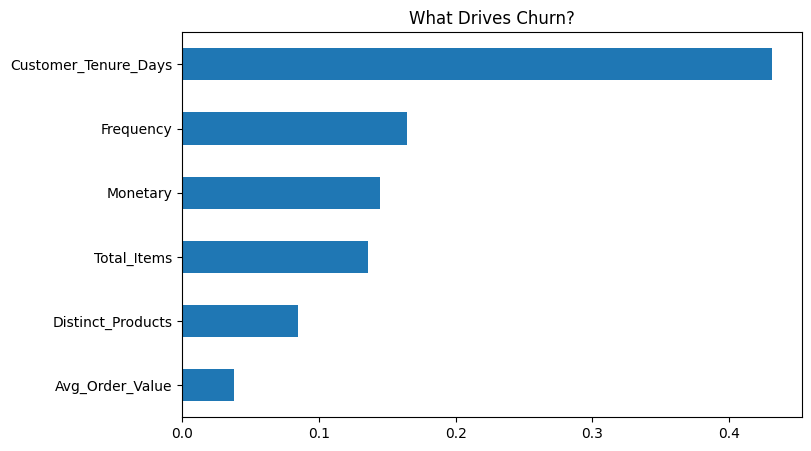

In [18]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8,5), title='What Drives Churn?')
plt.gca().invert_yaxis()
plt.show()

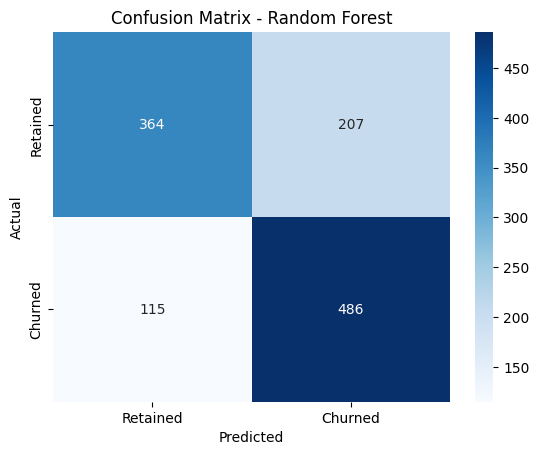

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()